# Smart MCQ Solver Challenge 

***dl-genai project t22026***

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


## Load datasets

In [3]:
df1 = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
df2 = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

In [4]:
print("Train Shape:", df1.shape)
print("Test Shape:", df2.shape)
print("Sample Shape:", sample.shape)

Train Shape: (2000, 8)
Test Shape: (500, 7)
Sample Shape: (500, 2)


## Import necessary libraries

In [5]:
# DATA LOADING & BASIC EDA

import warnings
warnings.filterwarnings("ignore")

import os
import re
import string
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

# NLP
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
STOP_WORDS = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## EDA

In [6]:
df1.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [7]:
df2.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [8]:
print("="*60)
print("TRAIN INFO")
print("="*60)

df1.info()

print("="*60)
print("TEST INFO")
print("="*60)

df2.info()

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB
TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memor

In [9]:
## Dataset summary
summary = pd.DataFrame({
    "Data Type": df1.dtypes,
    "Missing": df1.isnull().sum(),
    "Missing %": (
        df1.isnull().sum()/len(df1)
    )*100,
    "Unique Values": df1.nunique()
})

summary

,Data Type,Missing,Missing %,Unique Values
id,int64,0,0.0,2000
prompt,object,0,0.0,1758
A,object,0,0.0,316
B,object,0,0.0,328
C,object,0,0.0,303
D,object,0,0.0,318
E,object,0,0.0,320
answer,object,0,0.0,5


In [10]:
## Memory Uses
memory = df1.memory_usage(deep=True)/1024**2

memory = memory.sort_values(ascending=False)

memory

B         0.478772
E         0.475572
C         0.473591
A         0.470795
D         0.457014
prompt    0.321818
answer    0.095367
id        0.015259
Index     0.000126
dtype: float64

In [11]:
## Describe Numerical Columns
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2000.0,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0


In [12]:
### Describe Object Columns
df1.describe(include="object").T

,count,unique,top,freq
prompt,2000,1758,Select the most accurate option: How do the Lu...,4
A,2000,316,An improper rotation is the combination of a r...,21
B,2000,328,An improper rotation is the combination of a r...,21
C,2000,303,An improper rotation is the combination of a r...,21
D,2000,318,An improper rotation is the combination of a r...,21
E,2000,320,An improper rotation is the combination of a r...,21
answer,2000,5,B,490


In [13]:
## Keep original data as new dataframe
train = df1.copy()
test = df2.copy()

### Check missisng values

In [14]:
### Missing Values- Missing Table
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

Series([], dtype: int64)

In [15]:
### Missing Percentage
missing_percent = (train.isnull().mean()*100).sort_values(ascending=False)

missing_percent

id        0.0
prompt    0.0
A         0.0
B         0.0
C         0.0
D         0.0
E         0.0
answer    0.0
dtype: float64

### Duplicate Analysis

In [16]:
### Duplicate Analysis
### Entire Row Duplicates
duplicate_rows = train.duplicated().sum()

print("Duplicate Rows :", duplicate_rows)

Duplicate Rows : 0


In [17]:
### Duplicate Prompts
duplicate_prompts = train["prompt"].duplicated().sum()

print("Duplicate Prompts :", duplicate_prompts)

Duplicate Prompts : 242


In [18]:
### Duplicate IDs
duplicate_ids = train["id"].duplicated().sum()

print("Duplicate IDs :", duplicate_ids)

Duplicate IDs : 0


In [19]:
### Duplicate Questions + Options
question_cols = ["prompt", "A", "B", "C", "D", "E"]

duplicates = train.duplicated(subset=question_cols).sum()

print("Duplicate Questions :", duplicates)

Duplicate Questions : 183


In [20]:
### Duplicate Summary Table
duplicate_summary = pd.DataFrame({
    "Type":["Entire Row", "Prompt", "Question+Options", "ID"],

    "Count":[
        duplicate_rows,
        duplicate_prompts,
        duplicates,
        duplicate_ids
    ]})

duplicate_summary

,Type,Count
0,Entire Row,0
1,Prompt,242
2,Question+Options,183
3,ID,0


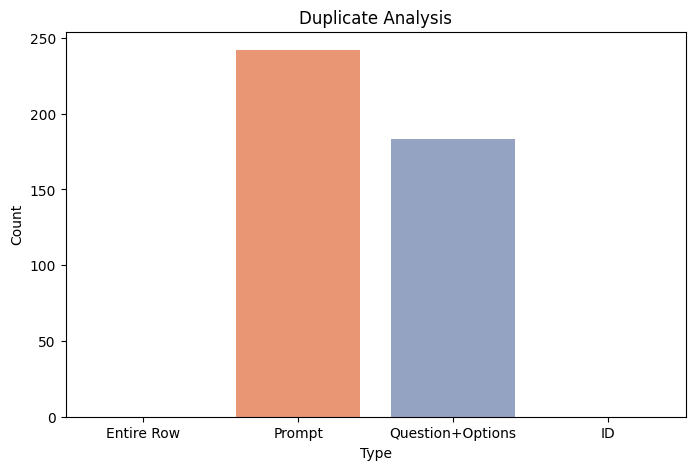

In [21]:
### Duplicate Chart
plt.figure(figsize=(8,5))

sns.barplot(data=duplicate_summary, x="Type", y="Count", palette="Set2")

plt.title("Duplicate Analysis")

plt.show()

### Basic Text Statistics

In [22]:
## Basic Text Statistics
## Prompt Length
option_cols = ["A","B","C","D","E"]

train["prompt_length"] = train["prompt"].astype(str).str.len()

for col in option_cols:
    train[f"{col}_length"] = (
        train[col].astype(str).str.len()
    )

train["combined_text"] = (
    train["prompt"] + " " +
    train["A"] + " " +
    train["B"] + " " +
    train["C"] + " " +
    train["D"] + " " +
    train["E"]
)

train["combined_length"] = (
    train["combined_text"]
    .str.len()
)

In [23]:
## Word Count
train["prompt_word_count"] = (train["prompt"].astype(str).apply(lambda x:len(x.split())))

In [24]:
## Sentence Count
train["num_sentences"] = (train["prompt"].str.count(r"[.!?]")+1)

In [25]:
## Digit Count
train["num_digits"] = (train["prompt"].str.count(r"\d"))

In [26]:
### Punctuation Count
import string
train["punct_count"] = (train["prompt"].apply(lambda x:sum(c in string.punctuation for c in str(x))))

In [27]:
### Statistics Table

train[
[
"prompt_length",
"combined_length",
"A_length",
"B_length",
"C_length",
"D_length",
"E_length",
"prompt_word_count",
"num_sentences",
"num_digits",
"punct_count"
]
].describe()

,prompt_length,combined_length,A_length,B_length,C_length,D_length,E_length,prompt_word_count,num_sentences,num_digits,punct_count
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,117.669500,947.398000,164.091500,166.616500,167.227000,162.56350,164.230000,18.14650,2.883500,0.218500,3.371000
std,44.408674,521.720751,105.677145,113.829917,105.723674,104.11657,107.777712,6.78189,0.584892,1.113273,1.330129
min,19.000000,89.000000,1.000000,2.000000,2.000000,1.00000,2.000000,3.00000,2.000000,0.000000,1.000000
25%,87.750000,571.000000,86.000000,82.000000,88.000000,91.00000,84.000000,14.00000,3.000000,0.000000,3.000000
50%,111.000000,875.500000,143.000000,151.000000,158.000000,141.00000,144.000000,17.00000,3.000000,0.000000,3.000000
75%,141.000000,1263.000000,234.000000,222.000000,224.000000,231.00000,224.000000,22.00000,3.000000,0.000000,4.000000
max,337.000000,2608.000000,472.000000,662.000000,530.000000,450.00000,587.000000,51.00000,5.000000,8.000000,8.000000


In [28]:
### Word Count Analysis 

train["prompt_words"] = (
    train["prompt"]
    .str.split()
    .apply(len)
)

train["combined_words"] = (
    train["combined_text"]
    .str.split()
    .apply(len)
)

train[[
"prompt_words",
"combined_words"]].describe()

,prompt_words,combined_words
count,2000.00000,2000.000000
mean,18.14650,149.544500
std,6.78189,85.412603
min,3.00000,15.000000
25%,14.00000,88.000000
50%,17.00000,133.000000
75%,22.00000,202.000000
max,51.00000,457.000000


In [30]:
### Vocabulary Analysis

from collections import Counter

all_words = (
    " ".join(train["combined_text"])
    .lower()
    .split()
)

counter = Counter(all_words)

print("Vocabulary Size:",
      len(counter))

print("Total Tokens:",
      len(all_words))

print(counter.most_common(30))

Vocabulary Size: 3815
Total Tokens: 299089
[('the', 27166), ('of', 14606), ('a', 11729), ('is', 10182), ('and', 6917), ('in', 6660), ('to', 6298), ('that', 4428), ('by', 2153), ('an', 2054), ('which', 1944), ('on', 1923), ('are', 1904), ('from', 1833), ('or', 1826), ('as', 1810), ('what', 1809), ('for', 1766), ('with', 1647), ('it', 1329), ('used', 1272), ('be', 1212), ('at', 1199), ('between', 965), ('can', 899), ('correct', 893), ('light', 833), ('following', 746), ('not', 740), ('its', 719)]


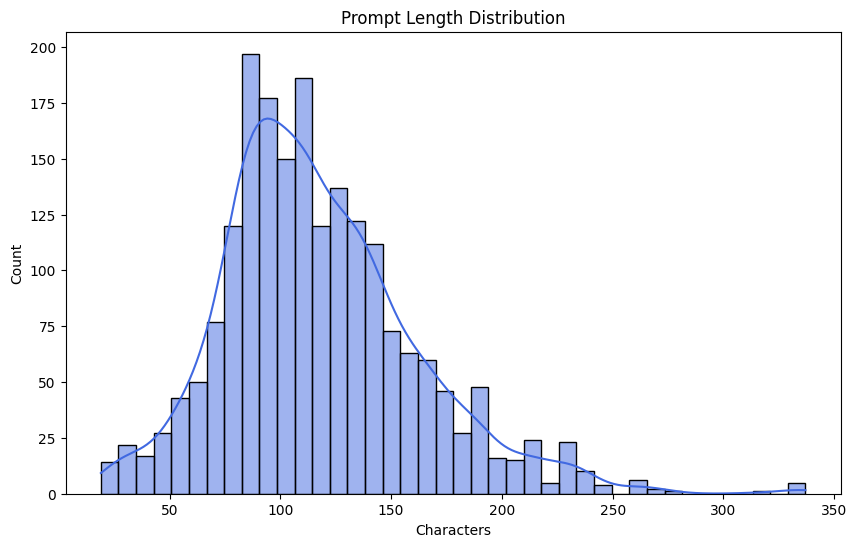

In [31]:
## Prompt Length Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    train["prompt_length"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Prompt Length Distribution")

plt.xlabel("Characters")

plt.show()

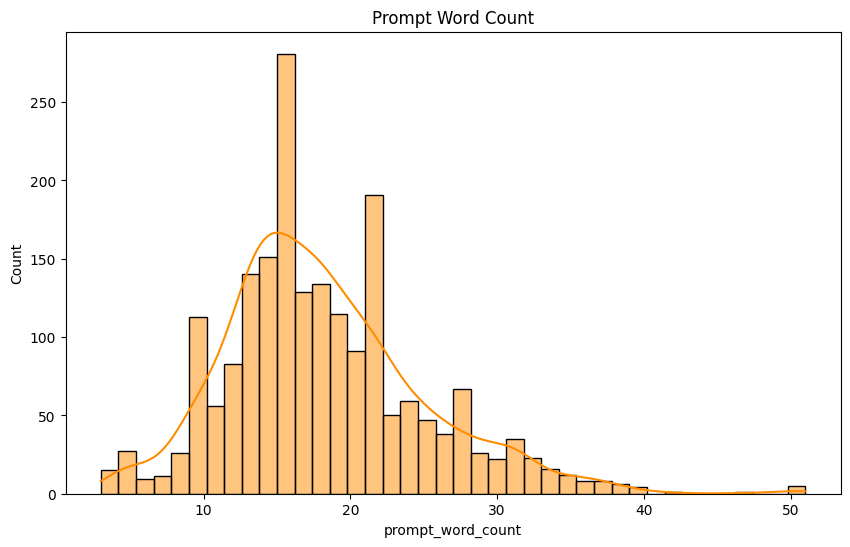

In [32]:
### Prompt Word Count Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    train["prompt_word_count"],
    bins=40,
    kde=True,
    color="darkorange"
)

plt.title("Prompt Word Count")

plt.show()


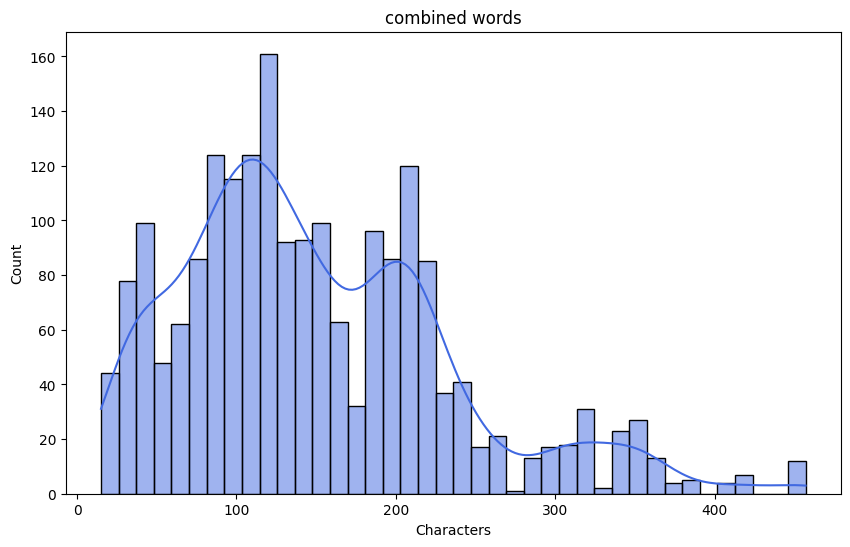

In [46]:
plt.figure(figsize=(10,6))

sns.histplot(
    train["combined_words"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("combined words")

plt.xlabel("Characters")

plt.show()

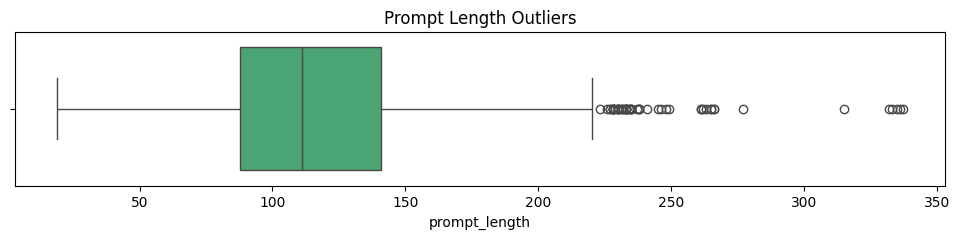

In [33]:
## Prompt Length Boxplot
plt.figure(figsize=(12,2))

sns.boxplot(
    x=train["prompt_length"],
    color="mediumseagreen"
)

plt.title("Prompt Length Outliers")

plt.show()


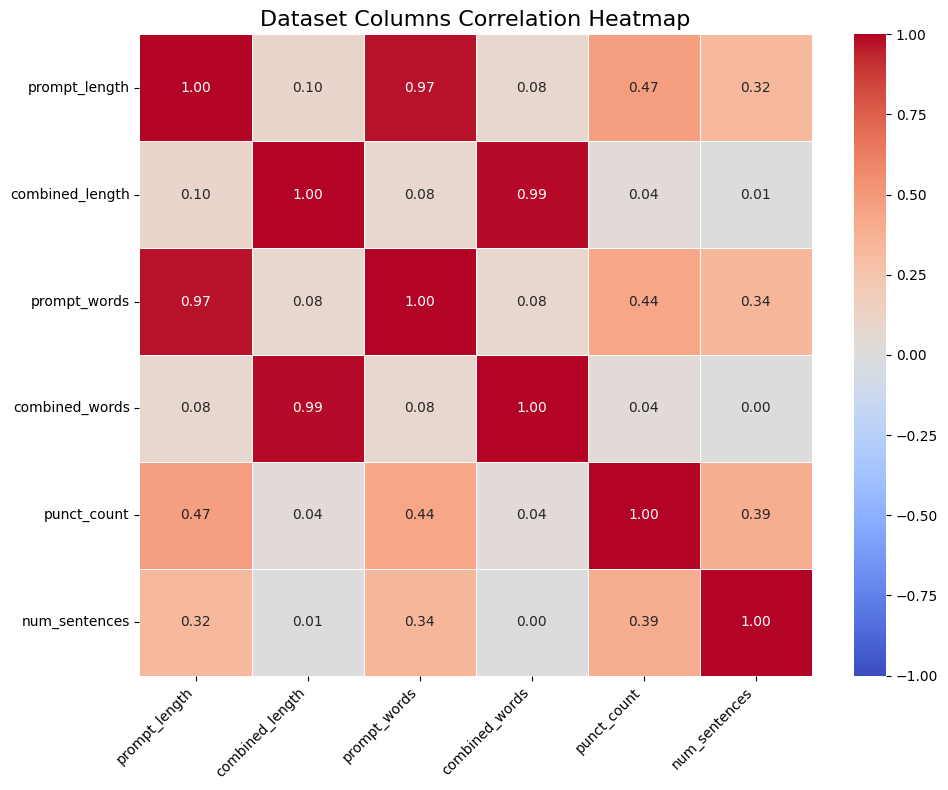

In [48]:
columns = ["prompt_length", "combined_length", "prompt_words", "combined_words", "punct_count", "num_sentences"]
corr_df = train[columns].corr()

# 2. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

# 3. Add titles and show
plt.title('Dataset Columns Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [49]:
option_cols = ["A", "B", "C", "D", "E"]

for col in option_cols:
    train[f"{col}_words"] = train[col].astype(str).str.split().str.len()

summary = train[[f"{c}_words" for c in option_cols]].describe()
print(summary)

           A_words      B_words     C_words      D_words      E_words
count  2000.000000  2000.000000  2000.00000  2000.000000  2000.000000
mean     26.146000    26.516000    26.54950    25.999500    26.187000
std      17.249651    18.653893    17.20987    17.098909    17.852658
min       1.000000     1.000000     1.00000     1.000000     1.000000
25%      13.000000    12.000000    14.75000    15.000000    13.000000
50%      22.000000    23.000000    24.00000    22.000000    23.000000
75%      37.000000    36.000000    36.00000    36.000000    36.000000
max      81.000000   118.000000    82.00000    78.000000   105.000000


In [34]:
### Rare Word Analysis
rare = sum(
    1 for word,count
    in counter.items()
    if count==1
)

print("Rare Words:",rare)

print(
"Rare Word Ratio:",
rare/len(counter)
)

Rare Words: 12
Rare Word Ratio: 0.003145478374836173


In [35]:
### Dataset Snapshot

display(train.head())

,id,prompt,A,B,C,D,E,answer,prompt_length,A_length,...,D_length,E_length,combined_text,combined_length,prompt_word_count,num_sentences,num_digits,punct_count,prompt_words,combined_words
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,142,307,...,202,191,Pick the best possible answer: What is Martin ...,1327,22,3,0,4,22,214
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A,43,406,...,407,408,What is accelerator-based light-ion fusion? Ac...,1998,5,2,0,3,5,295
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C,182,12,...,9,9,Determine the correct option: What is the term...,237,27,3,0,4,27,32
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,129,307,...,202,191,Select the most accurate option: What is Marti...,1314,19,3,0,4,19,211
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,110,230,...,99,99,Identify the correct statement: What is the co...,1009,15,3,0,5,15,153


In [36]:
### Lexical Diversity
def lexical(text):
    words=text.lower().split()
    return len(set(words))/len(words)

train["lexical"] = (
    train["combined_text"]
    .apply(lexical)
)

train["lexical"].describe()

count    2000.000000
mean        0.416432
std         0.194322
min         0.141026
25%         0.263158
50%         0.356379
75%         0.526882
max         1.000000
Name: lexical, dtype: float64

In [37]:
### Stopword Ratio
from nltk.corpus import stopwords

stop=set(stopwords.words("english"))

def stop_ratio(text):

    words=text.lower().split()

    if len(words)==0:
        return 0

    stop_count=sum(
        w in stop
        for w in words
    )

    return stop_count/len(words)

train["stop_ratio"] = (
    train["combined_text"]
    .apply(stop_ratio)
)

train["stop_ratio"].describe()

count    2000.000000
mean        0.423871
std         0.070940
min         0.142857
25%         0.385671
50%         0.435644
75%         0.466337
max         0.630435
Name: stop_ratio, dtype: float64

In [38]:
#### Tokenizer Analysis (MOST IMPORTANT)
### We will eventually use a tokenizer, but first estimate sequence lengths.

lengths = (
    train["combined_text"]
    .str.split()
    .apply(len)
)

print(lengths.describe())

print(np.percentile(lengths,50))
print(np.percentile(lengths,75))
print(np.percentile(lengths,90))
print(np.percentile(lengths,95))
print(np.percentile(lengths,99))
print(lengths.max())

count    2000.000000
mean      149.544500
std        85.412603
min        15.000000
25%        88.000000
50%       133.000000
75%       202.000000
max       457.000000
Name: combined_text, dtype: float64
133.0
202.0
257.10000000000014
322.0
412.0
457


In [39]:
### Train/Test Distribution Shift
test["combined_text"] = (
    test["prompt"]+" "+
    test["A"]+" "+
    test["B"]+" "+
    test["C"]+" "+
    test["D"]+" "+
    test["E"]
)

train["combined_words"] = (
    train["combined_text"]
    .str.split().apply(len)
)

test["combined_words"] = (
    test["combined_text"]
    .str.split().apply(len)
)

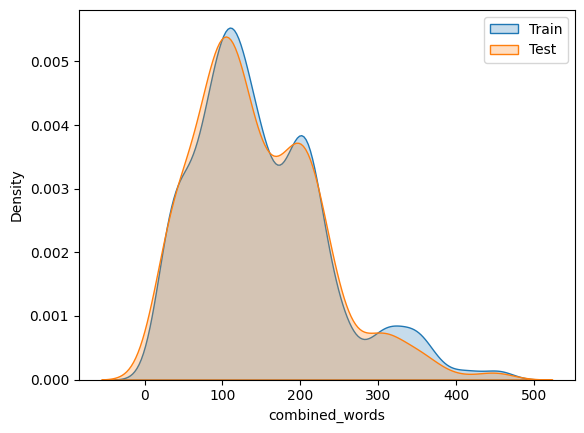

In [40]:
## Plot

sns.kdeplot(
    train["combined_words"],
    fill=True,
    label="Train"
)

sns.kdeplot(
    test["combined_words"],
    fill=True,
    label="Test"
)

plt.legend()
plt.show()

In [41]:
#### Vocabulary Coverage
train_vocab = set(
    " ".join(train["combined_text"])
    .lower().split()
)

test_vocab = set(
    " ".join(test["combined_text"])
    .lower().split()
)

coverage = (
    len(train_vocab & test_vocab)
    / len(test_vocab)
)

print(coverage)

0.9997367035281727


In [43]:
train.answer.value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

In [50]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

option_cols = ["A", "B", "C", "D", "E"]

correct_sim = []
wrong_sim = []

for _, row in train.iterrows():
    prompt_emb = model.encode(row["prompt"])

    for opt in option_cols:
        option_emb = model.encode(row[opt])

        sim = cosine_similarity(
            [prompt_emb],
            [option_emb]
        )[0][0]

        if opt == row["answer"]:
            correct_sim.append(sim)
        else:
            wrong_sim.append(sim)

print("Average Correct Similarity:", np.mean(correct_sim))
print("Average Wrong Similarity:", np.mean(wrong_sim))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Average Correct Similarity: 0.5826924
Average Wrong Similarity: 0.5743594


In [42]:
### Part 1 Summary
#### At the end of Part 1, include a concise summary to guide the next steps:

print("="*60)
print("PART 1 SUMMARY")
print("="*60)

print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
print(f"Duplicate Rows: {duplicate_rows}")
print(f"Duplicate Prompts: {duplicate_prompts}")
print(f"Duplicate Questions: {duplicates}")
print(f"Missing Cells: {train.isnull().sum().sum()}")
print(f"Average Prompt Length: {train['prompt_length'].mean():.2f}")
print(f"Maximum Prompt Length: {train['prompt_length'].max()}")
print(f"Average Word Count: {train['prompt_word_count'].mean():.2f}")
print("="*60)

PART 1 SUMMARY
Train Shape: (2000, 24)
Test Shape: (500, 9)
Duplicate Rows: 0
Duplicate Prompts: 242
Duplicate Questions: 183
Missing Cells: 0
Average Prompt Length: 117.67
Maximum Prompt Length: 337
Average Word Count: 18.15
